In [1]:
import pandas as pd 
orders = pd.read_csv('../data/raw/olist_orders_dataset.csv')
orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [2]:
date_columns = [
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date'
]

orders[date_columns] = orders[date_columns].apply(pd.to_datetime)
orders.info()

<class 'pandas.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       99441 non-null  str           
 1   customer_id                    99441 non-null  str           
 2   order_status                   99441 non-null  str           
 3   order_purchase_timestamp       99441 non-null  datetime64[us]
 4   order_approved_at              99281 non-null  datetime64[us]
 5   order_delivered_carrier_date   97658 non-null  datetime64[us]
 6   order_delivered_customer_date  96476 non-null  datetime64[us]
 7   order_estimated_delivery_date  99441 non-null  datetime64[us]
dtypes: datetime64[us](5), str(3)
memory usage: 6.1 MB


In [3]:
orders.shape

(99441, 8)

In [4]:
orders.isnull().sum()

order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

In [5]:
order_items = pd.read_csv('../data/raw/olist_order_items_dataset.csv')
products = pd.read_csv('../data/raw/olist_products_dataset.csv')
customers = pd.read_csv('../data/raw/olist_customers_dataset.csv')
reviews = pd.read_csv('../data/raw/olist_order_reviews_dataset.csv')
category_translation = pd.read_csv('../data/raw/product_category_name_translation.csv')

In [6]:
order_items.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


In [7]:
items_products = order_items.merge(products, on='product_id')
items_products.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29,cool_stuff,58.0,598.0,4.0,650.0,28.0,9.0,14.0
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93,pet_shop,56.0,239.0,2.0,30000.0,50.0,30.0,40.0
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87,moveis_decoracao,59.0,695.0,2.0,3050.0,33.0,13.0,33.0
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79,perfumaria,42.0,480.0,1.0,200.0,16.0,10.0,15.0
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14,ferramentas_jardim,59.0,409.0,1.0,3750.0,35.0,40.0,30.0


In [8]:
faturamento_categoria = items_products.groupby('product_category_name')['price'].sum().sort_values(ascending=False)
faturamento_categoria.head(10)

product_category_name
beleza_saude              1258681.34
relogios_presentes        1205005.68
cama_mesa_banho           1036988.68
esporte_lazer              988048.97
informatica_acessorios     911954.32
moveis_decoracao           729762.49
cool_stuff                 635290.85
utilidades_domesticas      632248.66
automotivo                 592720.11
ferramentas_jardim         485256.46
Name: price, dtype: float64

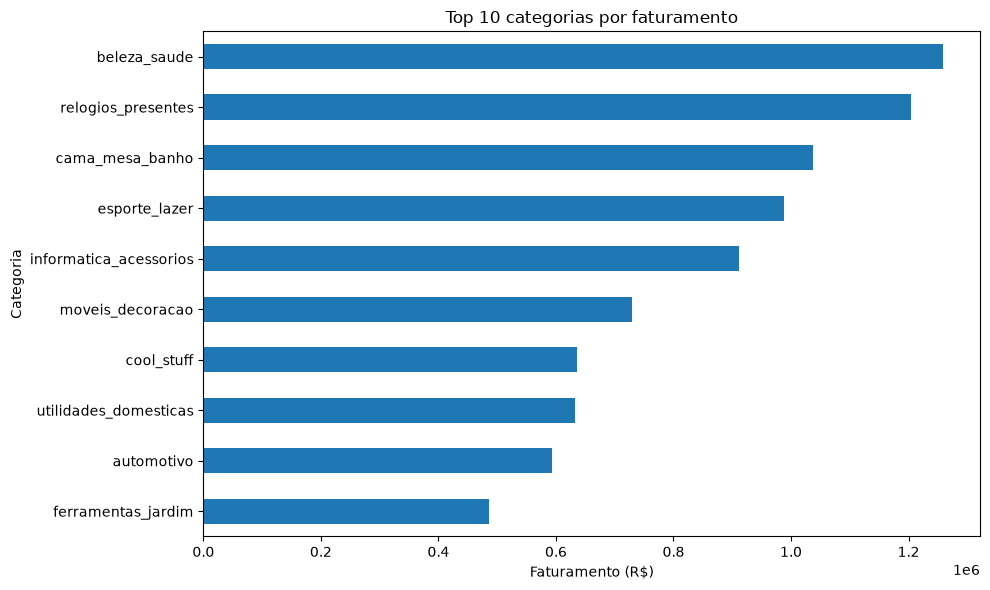

In [17]:
import matplotlib.pyplot as plt

faturamento_categoria.head(10).plot(kind='barh', figsize=(10,6))
plt.xlabel('Faturamento (R$)')
plt.ylabel('Categoria')
plt.title('Top 10 categorias por faturamento')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('../images/top_categorias.png', bbox_inches='tight')
plt.show()

In [10]:
orders['atraso_dias'] = (orders['order_delivered_customer_date'] - orders['order_estimated_delivery_date']).dt.days
orders['atraso_dias'].describe()

count    96476.000000
mean       -11.876881
std         10.183854
min       -147.000000
25%        -17.000000
50%        -12.000000
75%         -7.000000
max        188.000000
Name: atraso_dias, dtype: float64

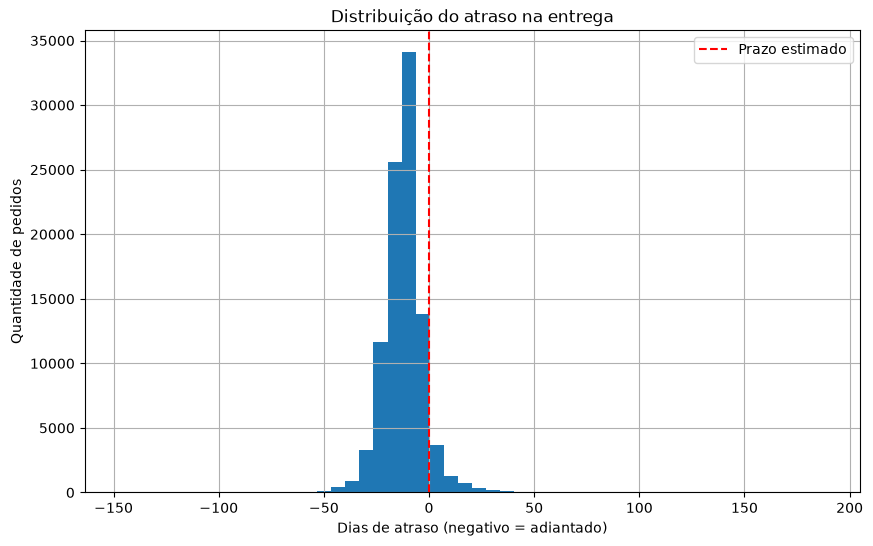

In [18]:
plt.figure(figsize=(10,6))
orders['atraso_dias'].hist(bins=50)
plt.xlabel('Dias de atraso (negativo = adiantado)')
plt.ylabel('Quantidade de pedidos')
plt.title('Distribuição do atraso na entrega')
plt.axvline(0, color='red', linestyle='--', label='Prazo estimado')
plt.legend()
plt.savefig('../images/distribuicao_atraso.png', bbox_inches='tight')
plt.show()

In [12]:
avaliacoes = reviews[['order_id', 'review_score']]
items_reviews = items_products.merge(avaliacoes, on='order_id')
items_reviews[['price', 'review_score']].describe()

,price,review_score
count,112372.000000,112372.000000
mean,120.378962,4.032473
std,182.152386,1.387849
min,0.850000,1.000000
25%,39.900000,4.000000
50%,74.900000,5.000000
75%,134.900000,5.000000
max,6735.000000,5.000000


In [13]:
preco_por_nota = items_reviews.groupby('review_score')['price'].mean()
preco_por_nota

review_score
1    127.350068
2    115.849138
3    110.059704
4    118.602628
5    121.219825
Name: price, dtype: float64

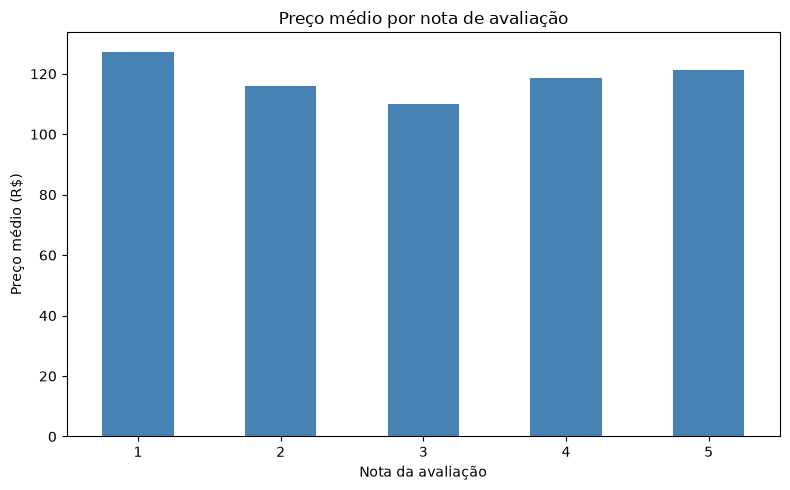

In [19]:
plt.figure(figsize=(8,5))
preco_por_nota.plot(kind='bar', color='steelblue')
plt.xlabel('Nota da avaliação')
plt.ylabel('Preço médio (R$)')
plt.title('Preço médio por nota de avaliação')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('../images/preco_por_nota.png', bbox_inches='tight')
plt.show()

In [15]:
orders['ano_mes'] = orders['order_purchase_timestamp'].dt.to_period('M')

vendas_orders = orders.merge(items_products, on='order_id')
vendas_mensais = vendas_orders.groupby('ano_mes')['price'].sum()
vendas_mensais

ano_mes
2016-09        267.36
2016-10      49507.66
2016-12         10.90
2017-01     120312.87
2017-02     247303.02
2017-03     374344.30
2017-04     359927.23
2017-05     506071.14
2017-06     433038.60
2017-07     498031.48
2017-08     573971.68
2017-09     624401.69
2017-10     664219.43
2017-11    1010271.37
2017-12     743914.17
2018-01     950030.36
2018-02     844178.71
2018-03     983213.44
2018-04     996647.75
2018-05     996517.68
2018-06     865124.31
2018-07     895507.22
2018-08     854686.33
2018-09        145.00
Freq: M, Name: price, dtype: float64

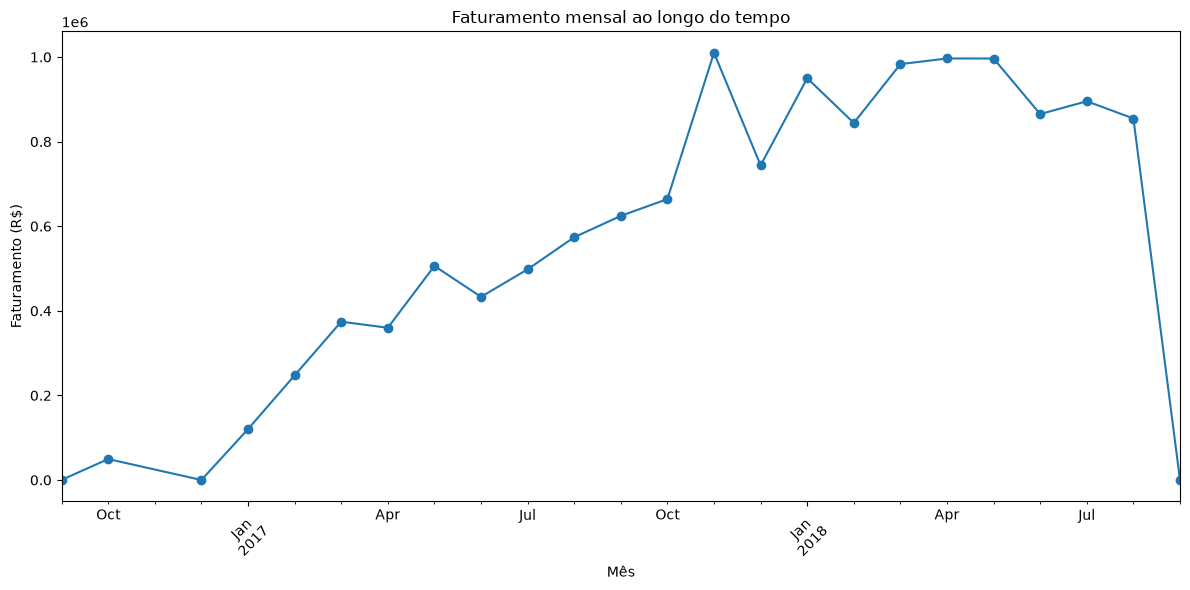

In [20]:
plt.figure(figsize=(12,6))
vendas_mensais.plot(kind='line', marker='o')
plt.xlabel('Mês')
plt.ylabel('Faturamento (R$)')
plt.title('Faturamento mensal ao longo do tempo')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('../images/vendas_mensais.png', bbox_inches='tight')
plt.show()

## Conclusões

- **Categorias mais vendidas**: beleza_saude, relogios_presentes e cama_mesa_banho lideram em faturamento, sugerindo forte demanda por produtos de consumo recorrente e presentes.
- **Entregas**: a maioria dos pedidos chega bem antes do prazo estimado (mediana de -12 dias), indicando que a Olist trabalha com estimativas conservadoras. Ainda assim, existem casos extremos de atraso (até 188 dias) que merecem investigação futura.
- **Preço x satisfação**: não há relação forte entre o preço do produto e a nota de avaliação, sugerindo que outros fatores (como prazo de entrega e qualidade) pesam mais na satisfação do cliente.
- **Sazonalidade**: as vendas cresceram consistentemente ao longo de 2017, com pico em novembro (Black Friday). A queda observada em setembro/2018 é resultado de dados incompletos no dataset, não uma queda real de vendas.